# CUT&RUN Trackplots


In [1]:
import subprocess
r = subprocess.run(["pyGenomeTracks", "--version"], capture_output=True, text=True)
if r.returncode == 0:
    print("pyGenomeTracks:", (r.stdout + r.stderr).strip().splitlines()[0])
else:
    print("WARNING: pyGenomeTracks not found on PATH.")
    print("Install: pip install pygenometracks")

pyGenomeTracks: 3.9


In [2]:
import os, glob, re, tempfile
from collections import defaultdict
import pandas as pd
from IPython.display import Image, display
import matplotlib
import matplotlib.colors as mc

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

In [3]:

PROJECT_DIR = ".."  # path to cutandrun_project/

#   y_max:      "auto" | 5.0 (all TFs same) | {"H3K4me3": 9.8, "Junb": 2.0}
#   highlights: list of region strings or (region, color) tuples
#     e.g. ["chr4:141_789_600-141_798_100"]
#     e.g. [("chr4:141_789_600-141_791_000", "#FFA500"),
#            ("chr4:141_793_000-141_795_000", "#00C000")]
GENE_CONFIG = {
    "Sfn": {}
}

CONDITION_COLORS = {"GFP": "Blue", "TFF1": "Red"}
TF_ORDER         = ["H3K4me3", "Fosb"]   # order tracks appear top-to-bottom
CONDITION_ORDER  = ["GFP", "TFF1"]
PEAKS_SOURCE     = "consensus"            # "consensus" | "replicates"

# ── Layout defaults (rarely changed) ─────────────────────────────────────────
LAYOUT = {
    "flank":           10_000,
    "y_max":           "auto",
    "show_peaks":      True,
    "track_height":    0.5,
    "peak_height":     0.4,
    "peak_display":    "squares",   # "squares" | "triangles" | "lines"
    "gene_height":     0.5,
    "gene_style":      "flybase",   # "UCSC" | "flybase" | "interlaced_exons"
    "gene_line_width": 0.1,
    "gene_spacer":     0.1,
    "bw_spacer":       0,
    "track_spacer":    0.2,
    "gene_font_size":  4,
    "track_font_size": 15,
    "peak_font_size":  8,
    "axis_font_size":  3,
    "width":           15,
    "highlights":      [],          # default: no highlights
}

GTF_PATH            = os.path.join(PROJECT_DIR, "7_deeptools/gencode.vM10.annotation.gtf")
MANIFEST_PATH       = os.path.join(PROJECT_DIR, "0_samplesheets/sample_manifest.tsv")
AVG_BW_DIR          = os.path.join(PROJECT_DIR, "8_trackplots/avg_bigwigs")
CONSENSUS_PEAKS_DIR = os.path.join(PROJECT_DIR, "7_deeptools/consensus_peaks")
PEAKS_DIR           = os.path.join(PROJECT_DIR, "3_peaks")
OUT_DIR             = os.path.join(PROJECT_DIR, "8_trackplots")
DPI                 = 300
ALPHA               = 0.85
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
# Expects: avg_bigwigs/{tf}_{condition}.avg.bigWig  (from 06_avg_bigwigs.sh)

manifest    = pd.read_csv(MANIFEST_PATH, sep="\t")
all_tfs     = sorted(manifest[~manifest["tf"].str.contains("IgG", case=False, na=False)]["tf"].unique())
all_conds   = sorted(manifest[~manifest["tf"].str.contains("IgG", case=False, na=False)]["group"].unique())

# averaged_bws[tf][condition] = path
averaged_bws = {}
rows = []
for tf in all_tfs:
    averaged_bws[tf] = {}
    for cond in all_conds:
        bw     = os.path.join(AVG_BW_DIR, f"{tf}_{cond}.avg.bigWig")
        exists = os.path.exists(bw)
        averaged_bws[tf][cond] = bw
        rows.append({"TF": tf, "Condition": cond, "Found": exists, "File": os.path.basename(bw)})

df      = pd.DataFrame(rows)
missing = df[~df["Found"]]
display(df)

if not missing.empty:
    print(f"\nWARNING: {len(missing)} averaged bigWig(s) not found.")
    print("  Run:  sbatch scripts/06_avg_bigwigs.sh")
else:
    print("\nAll averaged bigWigs found.")

,TF,Condition,Found,File
0,Fosb,GFP,True,Fosb_GFP.avg.bigWig
1,Fosb,TFF1,True,Fosb_TFF1.avg.bigWig
2,H3K4me3,GFP,True,H3K4me3_GFP.avg.bigWig
3,H3K4me3,TFF1,True,H3K4me3_TFF1.avg.bigWig
4,Junb,GFP,True,Junb_GFP.avg.bigWig
5,Junb,TFF1,True,Junb_TFF1.avg.bigWig



All averaged bigWigs found.


In [5]:

_gtf_cache = {}

def gene_coords(gene_name):
    """Return (chrom, start_0based, end, strand) for a GENCODE gene symbol.
    Results are cached after the first lookup.
    Raises ValueError if the symbol is not found.
    """
    if gene_name in _gtf_cache:
        return _gtf_cache[gene_name]
    pattern = re.compile(rf'gene_name "{re.escape(gene_name)}"')
    with open(GTF_PATH, "r") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 9 or fields[2] != "gene":
                continue
            if pattern.search(fields[8]):
                result = (fields[0], int(fields[3]) - 1, int(fields[4]), fields[6])
                _gtf_cache[gene_name] = result
                return result
    raise ValueError(f"Gene '{gene_name}' not found in GTF")

In [6]:
def lighten_color(hex_color, amount=0.55):
    c = mc.to_rgb(hex_color)
    return mc.to_hex(tuple(1 - amount * (1 - ch) for ch in c))


def _bw_block(section_id, bw_path, title, color, height, alpha, y_max, font_size):
    max_line = f"max_value = {y_max}" if y_max != "auto" else "# max_value = auto"
    return (
        f"[{section_id}]\n"
        f"file = {bw_path}\n"
        f"file_type = bigwig\n"
        f"title = {title}\n"
        f"height = {height}\n"
        f"color = {color}\n"
        f"min_value = 0\n"
        f"{max_line}\n"
        f"type = fill\n"
        f"alpha = {alpha}\n"
        f"number_of_bins = 700\n"
        f"show_data_range = true\n"
        f"fontsize = {font_size}\n\n"
    )


def _peak_block(section_id, bed_path, color, height, display_mode, font_size):
    light_color = lighten_color(color, 0.55)
    return (
        f"[{section_id}]\n"
        f"file = {bed_path}\n"
        f"file_type = bed\n"
        f"title = Cut & Run Peaks\n"
        f"height = {height}\n"
        f"color = {light_color}\n"
        f"border_color = none\n"
        f"display = {display_mode}\n"
        f"labels = false\n"
        f"fontsize = {font_size}\n\n"
    )


def _highlight_block(highlights, default_color="#00C000", default_border="none", alpha=0.25):
    """highlights: list of str | (str, color) | (str, color, border_color).
    Groups by (color, border_color); one BED + [highlight] block per group.
    Returns (ini_snippet, list_of_tmp_bed_paths).
    """
    if not highlights:
        return "", []
    groups = defaultdict(list)
    for item in highlights:
        if isinstance(item, str):
            color, border = default_color, default_border
            region = item
        elif len(item) == 2:
            region, color = item
            border = default_border
        else:
            region, color, border = item
        groups[(color, border)].append(region)
    ini_parts = []
    tmp_beds  = []
    for i, ((color, border), regions) in enumerate(groups.items()):
        rows = []
        for r in regions:
            r = r.replace("_", "")
            chrom, coords = r.split(":")
            start, end = coords.split("-")
            rows.append(f"{chrom}\t{start}\t{end}\n")
        tmp = tempfile.NamedTemporaryFile(
            suffix=".bed", mode="w", delete=False, prefix=f"highlight_{i}_"
        )
        tmp.writelines(rows)
        tmp.close()
        tmp_beds.append(tmp.name)
        ini_parts.append(
            f"[highlight_{i}]\n"
            f"file = {tmp.name}\n"
            f"type = vhighlight\n"
            f"color = {color}\n"
            f"border_color = {border}\n"
            f"alpha = {alpha}\n\n"
        )
    return "".join(ini_parts), tmp_beds


def _resolve_peak_bed(tf, cond):
    if PEAKS_SOURCE == "consensus":
        bed = os.path.join(CONSENSUS_PEAKS_DIR, f"{tf}_{cond}.consensus.bed")
        return bed if os.path.exists(bed) else None
    else:
        matches = sorted(glob.glob(os.path.join(PEAKS_DIR, f"{cond}_{tf}.seacr.peaks.relaxed.bed")))
        return matches[0] if matches else None


def _resolve_y_max(y_max, tf):
    if isinstance(y_max, dict):
        return y_max.get(tf, "auto")
    return y_max


def make_ini(tf_order, condition_order, track_height, y_max, show_peaks,
             peak_height, peak_display, gene_height, gene_style, gene_line_width,
             gene_spacer, bw_spacer, track_spacer, gene_font_size, track_font_size,
             peak_font_size, axis_font_size, highlights):
    highlight_ini, hl_beds = _highlight_block(highlights)
    ini = []
    if highlight_ini:
        ini.append(highlight_ini)
    ini.append(
        "[genes]\n"
        f"file = {GTF_PATH}\n"
        "file_type = gtf\n"
        f"height = {gene_height}\n"
        f"fontsize = {gene_font_size}\n"
        f"style = {gene_style}\n"
        f"line_width = {gene_line_width}\n"
        "merge_transcripts = true\n"
        "prefered_name = gene_name\n"
        "labels = true\n"
        "max_labels = 500\n\n"
    )
    ini.append(f"[spacer]\nheight = {gene_spacer}\n\n")
    for tf in tf_order:
        if tf not in averaged_bws:
            continue
        tf_y_max = _resolve_y_max(y_max, tf)
        conds_present = [c for c in condition_order
                         if c in averaged_bws[tf] and os.path.exists(averaged_bws[tf][c])]
        for i, cond in enumerate(conds_present):
            bw    = averaged_bws[tf][cond]
            color = CONDITION_COLORS.get(cond, "#888888")
            ini.append(_bw_block(
                f"{tf}_{cond}", bw, f"{tf} {cond}",
                color, track_height, ALPHA, tf_y_max, track_font_size,
            ))
            if show_peaks:
                bed = _resolve_peak_bed(tf, cond)
                if bed:
                    ini.append(_peak_block(f"peaks_{tf}_{cond}", bed, color, peak_height, peak_display, peak_font_size))
            if bw_spacer > 0 and i < len(conds_present) - 1:
                ini.append(f"[spacer]\nheight = {bw_spacer}\n\n")
        ini.append(f"[spacer]\nheight = {track_spacer}\n\n")
    ini.append(f"[x-axis]\nfontsize = {axis_font_size}\n")
    return "".join(ini), hl_beds

In [7]:
_last_kwargs = {}  # caches kwargs from the last plot_gene() call per gene


def _build_cfg_and_region(gene_name, kwargs):
    cfg = {
        **LAYOUT,
        "tf_order":        TF_ORDER,
        "condition_order": CONDITION_ORDER,
        **GENE_CONFIG.get(gene_name, {}),
        **kwargs,
    }
    region_override = cfg.get("region")
    if region_override is not None:
        region_str = region_override.replace("_", "")
        label = f"{gene_name}  [{region_str}]"
    else:
        try:
            chrom, start, end, strand = gene_coords(gene_name)
        except ValueError as e:
            print(f"[{gene_name}] SKIPPED — {e}")
            return None, None, None
        flank      = cfg["flank"]
        r_start    = max(0, start - flank)
        r_end      = end + flank
        region_str = f"{chrom}:{r_start}-{r_end}"
        label      = f"{gene_name}  [{chrom}:{start:,}–{end:,}  ±{flank/1e3:.0f} kb]"
    return cfg, region_str, label


def _run_pygt(gene_name, region_str, ini_content, out_path, width, hl_beds):
    ini_tmp = tempfile.NamedTemporaryFile(
        suffix=".ini", mode="w", delete=False, prefix=f"trackplot_{gene_name}_"
    )
    ini_tmp.write(ini_content)
    ini_tmp.close()
    cmd = [
        "pyGenomeTracks",
        "--tracks",      ini_tmp.name,
        "--region",      region_str,
        "--outFileName", out_path,
        "--dpi",         str(DPI),
        "--width",       str(width),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    os.unlink(ini_tmp.name)
    for bed in hl_beds:
        os.unlink(bed)
    if result.returncode != 0:
        print(f"  ERROR\n{result.stderr[-600:].strip()}")
        return False
    return True


def _make_ini_from_cfg(cfg):
    return make_ini(
        cfg["tf_order"], cfg["condition_order"], cfg["track_height"], cfg["y_max"],
        cfg["show_peaks"], cfg["peak_height"], cfg["peak_display"], cfg["gene_height"],
        cfg["gene_style"], cfg["gene_line_width"], cfg["gene_spacer"], cfg["bw_spacer"],
        cfg["track_spacer"], cfg["gene_font_size"], cfg["track_font_size"],
        cfg["peak_font_size"], cfg["axis_font_size"], cfg.get("highlights", []),
    )


def plot_gene(gene_name, **kwargs):
    """View a gene inline as a temporary PNG. Nothing is saved to disk."""
    _last_kwargs[gene_name] = kwargs  # save_gene() will reuse these if called with no args
    cfg, region_str, label = _build_cfg_and_region(gene_name, kwargs)
    if cfg is None:
        return
    print(f"Plotting {label}")
    ini_content, hl_beds = _make_ini_from_cfg(cfg)
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
        tmp_path = f.name
    ok = _run_pygt(gene_name, region_str, ini_content, tmp_path, cfg["width"], hl_beds)
    if ok and os.path.exists(tmp_path):
        display(Image(filename=tmp_path))
    if os.path.exists(tmp_path):
        os.unlink(tmp_path)


def save_gene(gene_name, **kwargs):
    """Save one gene as a PDF. With no kwargs, reuses the last plot_gene() settings."""
    if not kwargs and gene_name in _last_kwargs:
        kwargs = _last_kwargs[gene_name]
    cfg, region_str, label = _build_cfg_and_region(gene_name, kwargs)
    if cfg is None:
        return None
    print(f"Saving {label}")
    ini_content, hl_beds = _make_ini_from_cfg(cfg)
    out_path = os.path.join(OUT_DIR, f"{gene_name}.trackplot.pdf")
    ok = _run_pygt(gene_name, region_str, ini_content, out_path, cfg["width"], hl_beds)
    if ok:
        print(f"  → {os.path.relpath(out_path, PROJECT_DIR)}")
        return out_path
    return None


def save_all(**kwargs):
    """Save every gene in GENE_CONFIG as a PDF, using each gene's last plot_gene() settings."""
    for gene in GENE_CONFIG:
        save_gene(gene, **kwargs)
        print()

Plotting Sfn  [chr4:133,600,555–133,602,168  ±10 kb]


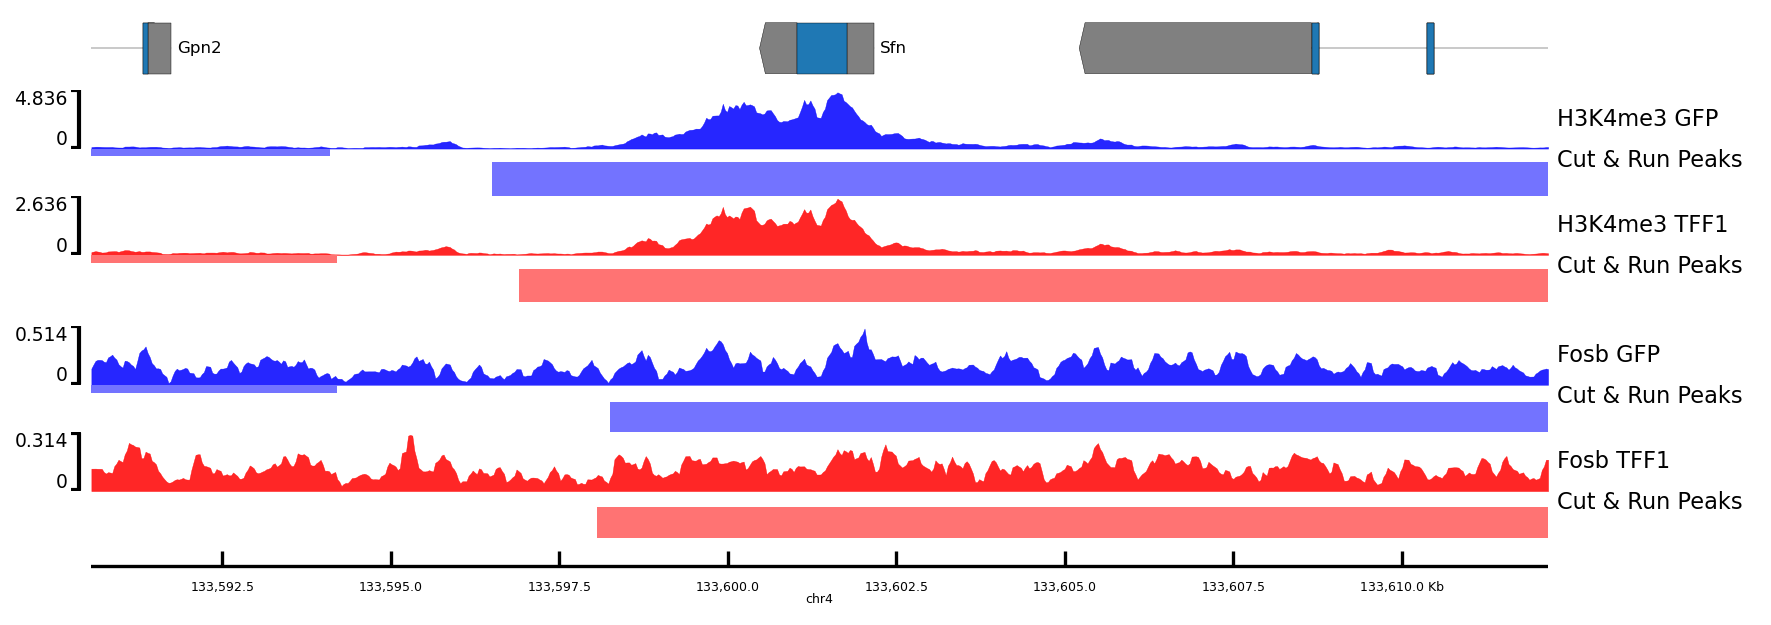

In [8]:
# Uses each gene's GENE_CONFIG settings (falling back to LAYOUT).
# Nothing is saved to disk — run Cell 9 when plots look right.

for gene in GENE_CONFIG:
    plot_gene(gene)
    print()

Plotting Sfn  [chr4:133598050-133603000]


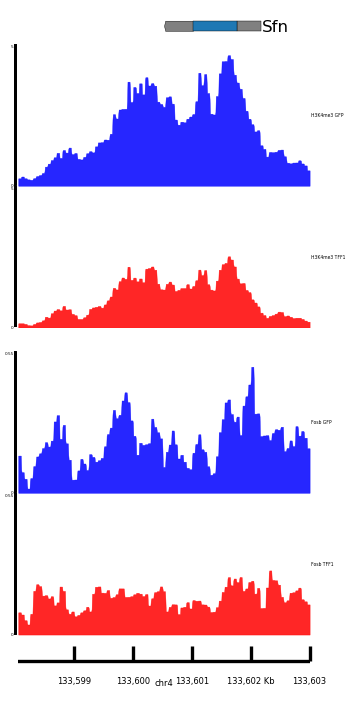

Saving Sfn  [chr4:133598050-133603000]
  → 8_trackplots/Sfn.trackplot.pdf


'../8_trackplots/Sfn.trackplot.pdf'

In [10]:
plot_gene("Sfn",
          y_max = {"H3K4me3": 5, "Fosb": 0.55} , 
          show_peaks = False, 
          gene_height = 0.1, 
          gene_style ='flybase', 
          track_height = 1.2, 
          gene_space = 0.1,
          gene_line_width = 0.1,
          track_spacer = 0.2,
          region = "chr4:133_598_050-133_603_000",
          
          gene_font_size = 4,
          track_font_size = 15, 
          axis_font_size = 2,
          width = 3, 
         )

          #highlight_regions = ["chr8:11_553_750-11_559_450"],
          #highlight_color= '#A9A9A9', 
save_gene("Sfn")

In [ ]:
plot_gene("Ptpru",
          y_max      = {"H3K4me3": 6.6},
          show_peaks = False)
# save_gene("Ptpru")